In [21]:
import tensorflow as tf

In [22]:
from tensorflow import keras 
import matplotlib.pyplot as plt
%matplotlib inline 
import numpy as np

In [23]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()   # mnist has handwritten digits

In [24]:
len(X_train)

60000

In [25]:
X_train[0].shape

(28, 28)

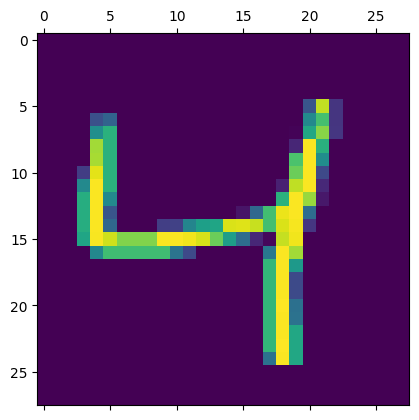

In [26]:
plt.matshow(X_train[2])

In [27]:
y_train[2]

np.uint8(4)

In [28]:
X_train = X_train/255
X_test = X_test/255

Dense neural networks only understand 1D input, and images are 2D, so we flatten it

In [29]:
X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_train_flattened.shape

(60000, 784)

In [30]:
X_test_flattened = X_test.reshape(len(X_test), 28*28)
X_test_flattened.shape

(10000, 784)

In [34]:
import warnings
warnings.filterwarnings('ignore')

In [35]:
model = keras.Sequential([
    keras.layers.Dense(10, input_shape = (784,), activation = 'sigmoid')
])

# 10 is the output size, input size is (784,) bcoz each image is 28*28, after flattening its 784. activation sigmoid will convert raw outputs into range(0,1). 

In [ ]:
model.compile(
    optimizer = 'adam', 
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']     # it will show the accuracy while training.
)
model.fit(X_train_flattened, y_train, epochs = 10)
# Epoch is the number of times the model learns from the full training data.
# optimizer = adam -> how weights are updated
# loss -> how wrong the model is
# sparse_categorical_crossentropy: A loss function used for multi-class classification when labels are integers.
# adam: An algorithm that updates model weights to reduce loss efficiently.

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9352 - loss: 0.2365
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9343 - loss: 0.2358
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9350 - loss: 0.2351
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9350 - loss: 0.2350
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9355 - loss: 0.2348
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9352 - loss: 0.2340
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9357 - loss: 0.2339
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9356 - loss: 0.2333
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9359 - loss: 0.2329
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9354 - loss: 0.2328


In [40]:
model.evaluate(X_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9261 - loss: 0.2769


[0.27686575055122375, 0.9261000156402588]

predictions

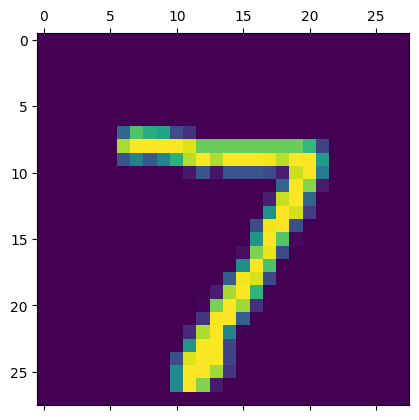

In [41]:
plt.matshow(X_test[0])

In [42]:
y_pred = model.predict(X_test_flattened)
y_pred[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 752us/step


array([6.5356921e-06, 1.1059392e-11, 6.2819738e-05, 9.6335846e-01,
       3.3966478e-04, 6.7620024e-02, 1.7568728e-12, 9.9987805e-01,
       2.7770648e-02, 5.4002225e-01], dtype=float32)

In [ ]:
np.argmax(y_pred[0])  

np.int64(7)

model.predict() gives probabilities for all digits, and argmax() picks the digit with the highest probability.

In [44]:
y_pred_labels = [np.argmax(i) for i in y_pred]
y_pred_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [45]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [46]:
cm = tf.math.confusion_matrix(labels = y_test, predictions = y_pred_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 959,    0,    1,    2,    1,    7,    5,    4,    1,    0],
       [   0, 1115,    5,    1,    0,    1,    3,    2,    8,    0],
       [   6,    9,  929,   16,   10,    3,    9,   12,   35,    3],
       [   3,    0,   15,  929,    2,   25,    1,   10,   20,    5],
       [   2,    3,    7,    3,  915,    0,    5,   11,    7,   29],
       [   9,    3,    3,   32,    9,  786,   10,    9,   28,    3],
       [  13,    3,   13,    1,    9,   21,  896,    1,    1,    0],
       [   1,    8,   20,    5,    4,    1,    0,  959,    2,   28],
       [   9,   12,    6,   25,    9,   29,    6,   11,  856,   11],
       [  10,    8,    1,    9,   24,    6,    0,   29,    5,  917]],
      dtype=int32)>

Text(50.722222222222214, 0.5, 'Actual')

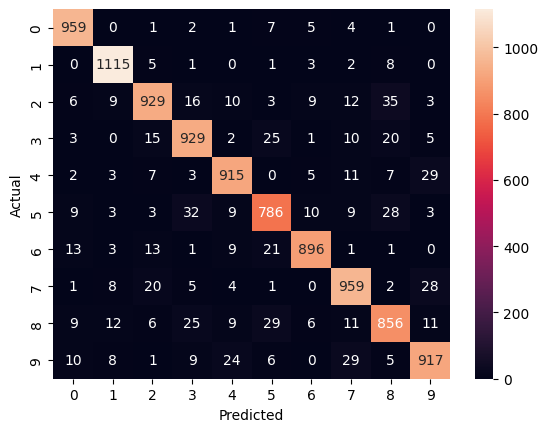

In [47]:
import seaborn as sns
sns.heatmap(cm, annot = True, fmt = 'd')
plt.xlabel('Predicted')
plt.ylabel('Actual')

adding a hidden layer tends to improve the performance of the model. so adding hidden layer into the model

In [ ]:
# [
#   Dense(100),   # hidden layer. 100 --> no. of neurons in hidden layer.
#   Dense(10)     # output layer
# ]

In [48]:
model = keras.Sequential([
    keras.layers.Dense(100, input_shape = (784,), activation = 'relu'),
    keras.layers.Dense(10, activation = 'sigmoid')
])

Why relu in hidden layer?

Because:
- ReLU adds non-linearity
- Helps learn complex patterns
- Trains faster

In [49]:
model.compile(
    optimizer = 'adam', 
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']     # it will show the accuracy while training.
)
model.fit(X_train_flattened, y_train, epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9218 - loss: 0.2766
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9619 - loss: 0.1285
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9737 - loss: 0.0890
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9798 - loss: 0.0681
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9839 - loss: 0.0529
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9872 - loss: 0.0428
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9890 - loss: 0.0351
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9918 - loss: 0.0275
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9929 - loss: 0.0227
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9935 - loss: 0.0204


accuracy increased!

In [50]:
model.evaluate(X_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9765 - loss: 0.0829


[0.08291326463222504, 0.9764999747276306]

In [51]:
y_pred = model.predict(X_test_flattened)
y_pred_labels = [np.argmax(i) for i in y_pred]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step


Text(50.722222222222214, 0.5, 'Actual')

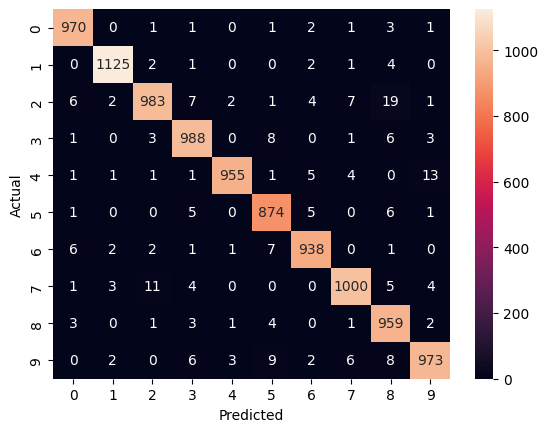

In [ ]:
cm = tf.math.confusion_matrix(labels = y_test, predictions = y_pred_labels)
sns.heatmap(cm, annot = True, fmt = 'd')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# errors reduced.

In [ ]:
# if we dont want to manually do the flattening

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9242 - loss: 0.2675
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9654 - loss: 0.1196
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9745 - loss: 0.0853
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9803 - loss: 0.0645
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9847 - loss: 0.0507
